In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.integrate import solve_ivp
from scipy.linalg import expm
import itertools
from itertools import product, combinations
import heapq
from math import comb
from math import factorial as fact
from scipy.signal import find_peaks


# automatically updates and reloads the imported functions from my own modules
%load_ext autoreload
%autoreload 2
    
import fourier_funcs
# import Epower_funcs

In [6]:

# def TDHFold(t,y):
#     rho = y.reshape(2*P,2*P)
#     d_rho = np.zeros_like(rho,dtype=complex)

#     h0 = np.zeros((2*P,2*P),dtype=complex)
#     for i in range(-P,P):
#         if i==0:
#             h0[i+P,i+P] = eps/2 * 1
#         else:
#             h0[i+P,i+P] = eps/2 * np.sign(i)

#     v = np.zeros((2*P,2*P,2*P,2*P),dtype=complex)
#     for i in range(P): # 0,1,2
#         for j in range(P):
#             v[i+P, j+P, i, j] = -V
#             v[i, j, i+P, j+P] = -V
#     v = v.reshape(4*P**2,4*P**2)

#     d_rho += comm(h0,rho)
    
#     rhorho = np.kron(rho,rho).reshape(2*P,2*P,2*P,2*P) # axis 0,2 is particle 1, axis 1,3 is particle 2. 
#     # now make the antisymmetrised 2body density
#     arho12 = ( rhorho - np.einsum('ijkl->ijlk',rhorho) ).reshape(4*P**2,4*P**2) # swap second axis of the two particles ie axes 2 and 3
    
#     comm2 = comm(v,arho12)
#     tr2 = np.einsum('ijkj->ik', comm2.reshape(2*P,2*P,2*P,2*P))
#     d_rho += tr2

#     d_rho = -1j*d_rho
#     return d_rho.ravel()



''' Observables: '''

def Ndown(rho):
    assert rho.shape[:2]==(2*P,2*P)
    assert rho.ndim==3
    yep = np.zeros(2*P,dtype=complex)
    for p in range(P):
        yep[p]=1.0
    down = np.outer(yep,yep)
    return np.einsum('ijt,ji->t',rho,down)
    

def Nup(rho):
    assert rho.shape[:2]==(2*P,2*P)
    assert rho.ndim==3
    yep = np.zeros(2*P,dtype=complex)
    for p in range(P):
        yep[p+P]=1.0
    up = np.outer(yep,yep)
    return np.einsum('ijt,ji->t',rho,up)


def HFstatD(D,th,phi):
    # this is the observable for how much of the state D is in the HF stationary state determined by theta and phi
    if D.shape[:2] == ((2*P)**P,(2*P)**P):
        D = D.reshape(2*P,2*P,2*P,2*P,2*P,2*P, -1)
    if D.shape[:6] != (2 * P,) * 6: 
        raise AttributeError("fix shape of density matrix")
    p1 = np.array([np.cos(th/2),0,0,np.exp(-1j*phi)*np.sin(th/2),0,0],dtype=complex)
    p2 = np.array([0,np.cos(th/2),0,0,np.exp(-1j*phi)*np.sin(th/2),0],dtype=complex)
    p3 = np.array([0,0,np.cos(th/2),0,0,np.exp(-1j*phi)*np.sin(th/2)],dtype=complex)
    psiin = np.einsum('i,j,k->ijk',p1,p2,p3)
    slat = 1/np.sqrt(6)*( psiin 
              -np.einsum('ijk->ikj',psiin)
              -np.einsum('ijk->jik',psiin)
              +np.einsum('ijk->jki',psiin)
              +np.einsum('ijk->kij',psiin)
              -np.einsum('ijk->kji',psiin)  )
    ex = np.einsum('ijk,ijklmnt,lmn->t', slat.conj(), D, slat)
    return ex

def HFstat(rho,th,phi):
    # this is the observable for how much of the state rho is in the HF stationary state determined by theta and phi
    # do Tr(rho |min><min|)
    assert rho.shape[:2] == (2*P,2*P) # ie the 1body rho
    static = np.zeros(2*P,dtype=complex)
    for i in range(P):
        static[i] = np.cos(th/2)
        static[i+P] = np.exp(-1j*phi)*np.sin(th/2)
    observ = np.outer(static,static.conj())
    if rho.ndim==2:
        trace = np.einsum('ij,ji->',rho,observ)
    if rho.ndim==3:
        trace = np.einsum('ijt,ji->t',rho,observ)
    return trace


def build_rho2(n, c2):
    """rho2[a,b,a',b'] = <c+_a' c+_b' c_b c_a> = A(nn) + C2."""
    Ann = (np.einsum('act,bdt->abcdt', n, n)
         - np.einsum('adt,bct->abcdt', n, n))
    return Ann + c2


def lower_occupation(n, c2, N=None):
    """
    Particles in the bottom level, for index ordering
    (-1..-P, +1..+P)  ->  lower block is 0:P.

    Returns mean, variance, and the trace-relation residual.
    """
    if N is None:
        N = P   # particle number
    lo = slice(0, P)

    # --- mean: one-body only ---
    mean = np.einsum('aat->t', n[lo, lo,:]).real

    # --- variance: needs rho2 ---
    # <N_-^2> = <N_-> + sum_{a,b in lower} rho2[a,b,a,b]
    rho2 = build_rho2(n, c2)
    pair = np.einsum('ababt->t', rho2[lo, lo, lo, lo,:]).real
    var = mean + pair - mean**2

    # --- consistency: sum_b rho2[a,b,a',b] = (N-1) n[a,a'] ---
    contracted = np.einsum('abcbt->act', rho2)
    residual = np.abs(contracted - (N - 1) * n).max()

    return mean, var, residual


def Jobservables(n):
    # DHF minima are at <J_x> = sign*P/2*sin(2a)
    Jp = np.trace(n[:P, P:])  # <J_+>, this is sum_p n_-p,p
    Jz = 0.5*(np.trace(n[P:, P:]) - np.trace(n[:P, :P]))
    return Jp.real, Jp.imag, Jz.real    # <J_x>, <J_y>, <J_z>

def DHFobservable(a,n):
    mean = (np.cos(a)**2 *np.trace(n[:P,:P]) 
            + np.sin(a)**2 *np.trace(n[P:,P:]) 
            + np.sin(a)*np.cos(a)*(np.trace(n[P:,:P]) + np.trace(n[:P,P:])) )
    return mean

In [7]:
''' functions to save solution to another file '''

import os
from types import SimpleNamespace

SOLNDIR = 'solutions'
os.makedirs(SOLNDIR, exist_ok=True)

def soln_name(tag=''):
    return os.path.join(
        SOLNDIR,
        f'tddm_P{P}_V{V:.6g}_t{t_list[0]:g}-{t_list[-1]:g}_n{len(t_list)}{tag}.npz')

def save_soln(fname, soln, rtol=np.nan, atol=np.nan, note=''):
    np.savez(fname, t=soln.t, y=soln.y,
             P=P, eps=eps, V=V, chi=chi, TRUNCATION=TRUNCATION,
             rtol=rtol, atol=atol, nfev=soln.nfev, note=note)
    print(f'wrote {fname}  ({os.path.getsize(fname)/1e6:.1f} MB)')

def load_soln(fname):
    d = np.load(fname, allow_pickle=False)
    # guard: a stale cache from different parameters is worse than no cache
    if (int(d['P']) != P or not np.isclose(float(d['eps']), eps)
            or not np.isclose(float(d['V']), V) or str(d['TRUNCATION']) != TRUNCATION):
        raise ValueError(
            f"cached file is P={int(d['P'])}, eps={float(d['eps']):g}, V={float(d['V']):g}, "
            f"TRUNCATION={str(d['TRUNCATION'])}; current globals are P={P}, eps={eps}, "
            f"V={V:g}, TRUNCATION={TRUNCATION}. Delete the file or fix the globals.")
    print(f"loaded {fname}: {len(d['t'])} time points, nfev={int(d['nfev'])}")
    return SimpleNamespace(t=d['t'], y=d['y'])


In [8]:
def antisym_3_bra(X):
    assert X.shape == (2*P,2*P,2*P,2*P,2*P,2*P)
    return 1/6*( X 
              -np.einsum('abcijk->abcikj',X) 
              -np.einsum('abcijk->abcjik',X) 
              +np.einsum('abcijk->abcjki',X) 
              +np.einsum('abcijk->abckij',X) 
              -np.einsum('abcijk->abckji',X)  )

def antisym_3_ket(X):
    return 1/6*( X 
                -np.einsum('abcijk->acbijk',X) 
                -np.einsum('abcijk->bacijk',X) 
                +np.einsum('abcijk->bcaijk',X) 
                +np.einsum('abcijk->cabijk',X) 
                -np.einsum('abcijk->cbaijk',X) )

def antisym_3_full(X):
    return antisym_3_ket(antisym_3_bra(X))   # bra then ket (order doesn't matter, they commute)

In [66]:
# ---------------------------------------------------------------- statics
_STATIC = {}

def statics():
    """Build (h0, v, vbar, I) once per (P, eps, V) instead of every RHS call."""
    key = (P, eps, V)
    s = _STATIC.get(key)
    if s is None:
        v = Hv()
        s = (Hh0(), v, v - v.transpose(0, 1, 3, 2), np.eye(2*P, dtype=complex))
        _STATIC[key] = s
    return s


# _PATH_CACHE = {}

# def _es(subs, *ops):
#     """einsum with the contraction path computed once and reused."""
#     key = (subs, tuple(o.shape for o in ops))
#     path = _PATH_CACHE.get(key)
#     if path is None:
#         path = np.einsum_path(subs, *ops, optimize='optimal')[0]
#         _PATH_CACHE[key] = path
#     return np.einsum(subs, *ops, optimize=path)

from opt_einsum import contract_expression

_EXPR = {}

def _es(subs, *ops):
    """einsum compiled once per (subscripts, shapes) and reused."""
    key = (subs, tuple(o.shape for o in ops))
    expr = _EXPR.get(key)
    if expr is None:
        expr = contract_expression(subs, *[o.shape for o in ops])
        _EXPR[key] = expr
    return expr(*ops)


def Hh0():
    sign = np.concatenate([-np.ones(P), np.ones(P)])
    h0 = np.diag(eps/2 * sign).astype(complex)
    return h0

lo = lambda j: j        # level -(j+1),  j = 0..P-1
up = lambda j: P + j    # level +(j+1)

def Hv():
    """Bare <ab|v|a'b'> in Tohyama's convention (H_int = 1/2 sum v a+a+aa)."""
    v = np.zeros((2*P,)*4, dtype=complex)
    for j in range(P):
        for k in range(P):
            v[up(j), up(k), lo(j), lo(k)] = V   # (V/2) J_+^2
            v[lo(j), lo(k), up(j), up(k)] = V   # (V/2) J_-^2
    return v

def Hvbar():
    """<ab|v|a'b'>_A"""
    v = Hv()
    vbar = v - v.transpose(0, 1, 3, 2) 
    return vbar


def ematrix(n, h0=None, vbar=None):
    if h0 is None:
        h0, _, vbar, _ = statics()
    en = h0 + _es('aibj,ji->ab', vbar, n)
    return en


# equations for B P H from Gong1990, T from Tohyama2020

def Bterm(n, vbar, I2P):
    nb = I2P - n # delta - n
    Bterm = (_es('ijkl,ai,bj,kc,ld->abcd', vbar, nb, nb, n, n)
           - _es('ijkl,ai,bj,kc,ld->abcd', vbar, n, n, nb, nb))
    return Bterm

def Pterm(n, c2, v):
    m2 = (2*P)**2
    V2 = v.reshape(m2, m2)
    C2 = c2.reshape(m2, m2)
    # the two pure M^6 contractions are matmuls -> hand them to BLAS
    Pterm  = (V2 @ C2).reshape((2*P,)*4)        # 'abkl,klcd->abcd'
    Pterm -= (C2 @ V2).reshape((2*P,)*4)        # 'ijcd,abij->abcd'
    Pterm -= _es('ajkl,bj,klcd->abcd', v, n, c2)
    Pterm -= _es('ibkl,ai,lkdc->abcd', v, n, c2)
    Pterm += _es('ijcl,ld,abij->abcd', v, n, c2)
    Pterm += _es('ijkd,kc,abij->abcd', v, n, c2)
    return Pterm

def Hterm(n, c2, v):
    out = np.zeros((2*P,)*4, dtype=complex)
    # delta_{alpha,lam1}  ->  v[a,j,k,l]
    out += _es('ajkl,kc,bldj->abcd', v, n, c2)
    out -= _es('ajkl,kd,blcj->abcd', v, n, c2)
    out -= _es('ajkl,lc,kbjd->abcd', v, n, c2)
    out -= _es('ajkl,ld,kbcj->abcd', v, n, c2)
    # delta_{beta,lam2}   ->  v[i,b,k,l]
    out += _es('ibkl,ld,akci->abcd', v, n, c2)
    out -= _es('ibkl,lc,akdi->abcd', v, n, c2)
    out -= _es('ibkl,kd,alci->abcd', v, n, c2)
    out -= _es('ibkl,kc,alid->abcd', v, n, c2)
    # -delta_{lam3,alpha'} ->  v[i,j,c,l]
    out -= _es('ijcl,ai,bldj->abcd', v, n, c2)
    out += _es('ijcl,bi,aldj->abcd', v, n, c2)
    out += _es('ijcl,aj,bldi->abcd', v, n, c2)
    out += _es('ijcl,bj,alid->abcd', v, n, c2)
    # -delta_{lam4,beta'}  ->  v[i,j,k,d]
    out -= _es('ijkd,bj,akci->abcd', v, n, c2)
    out += _es('ijkd,aj,bkci->abcd', v, n, c2)
    out += _es('ijkd,bi,akcj->abcd', v, n, c2)
    out += _es('ijkd,ai,bkjc->abcd', v, n, c2)
    return out

def Tterm(c3, v):
    # c3[l1,l2,l3, l1',l2',l3']
    Tterm  = _es('aijk,jkbcid->abcd', v, c3)
    Tterm += _es('ibjk,jkacid->abcd', v, c3)
    Tterm -= _es('ijck,akbijd->abcd', v, c3)
    Tterm -= _es('ijkd,akbijc->abcd', v, c3)
    return Tterm


TRUNCATION = 'TDDM'      # 'TDDM' | 'RHO3ZERO'            | 'TDDM1' | 'TDDM2'

def build_c3(n, c2, v):
    # return None for plain TDDM so no M^6 array is ever allocated
    if TRUNCATION == 'TDDM':
        return None
    if TRUNCATION == 'RHO3ZERO':
        # rho3 = A(rrr) + A(rC2) + C3 = 0  =>  C3 = -(A(rrr) + A(rC2))
        rrr = np.einsum('il,jm,kn->ijklmn', n, n, n)
        rc  = np.einsum('il,jkmn->ijklmn', n, c2)
        return -(6.0*antisym_3_full(rrr) + 9.0*antisym_3_full(rc))
    raise NotImplementedError(TRUNCATION)


def TDDM(t, y):
    m = 2*P
    n  = y[:m**2].reshape(m, m)
    c2 = y[m**2:].reshape(m, m, m, m)

    h0, v, vbar, I2P = statics()
    en = ematrix(n, h0, vbar)

    # first EOM for 1body density n
    d_n  = en @ n - n @ en
    d_n += _es('aijk,jkbi->ab', v, c2)      # Eq (5): BARE v here, not vbar
    d_n -= _es('aijk,jkbi->ab', c2, v)      # (C2 is antisym in jk, so vbar would double this)

    # now EOM for 2body correlation matrix c2
    d_c2  = _es('al,lbcd->abcd', en, c2)
    d_c2 += _es('bl,alcd->abcd', en, c2)
    d_c2 -= _es('lc,abld->abcd', en, c2)
    d_c2 -= _es('ld,abcl->abcd', en, c2)

    # build B P H and T terms for c2 EOM
    d_c2 += Bterm(n, vbar, I2P)
    d_c2 += Pterm(n, c2, v)
    d_c2 += Hterm(n, c2, v)

    c3 = build_c3(n, c2, v)
    if c3 is not None:
        d_c2 += Tterm(c3, v)

    d_n  *= -1j
    d_c2 *= -1j

    return np.concatenate((d_n.ravel(), d_c2.ravel()))


def TDHF(t,y):
    m = 2*P
    n  = y.reshape(m, m)

    h0, v, vbar, I2P = statics()
    en = ematrix(n, h0, vbar)

    # EOM for 1body density n
    d_n  = en @ n - n @ en
    d_n  *= -1j
    return d_n.ravel()



P = 4 # number of particles, and degeneracy of each level ie 2P states total

eps = 1 # energy between levels
chi = 2
# V = -4 # interaction energy
# chi = np.abs(V)*(P-1)/eps
V = -chi*eps/(P-1)
print('V=',V)

V= -0.6666666666666666


In [27]:
import time

m = 2*P
y0 = np.zeros(m**2 + m**4, dtype=complex)
y0[:m**2] = np.eye(m).reshape(-1)   # any valid-shape y0 is fine for timing

t0 = time.perf_counter()
out = TDDM(0.0, y0)
t1 = time.perf_counter()
print(f"single call: {t1-t0:.4f} s")


single call: 0.5873 s


## TDDM calc ##

In [67]:
"""
Initial conditions
"""

'''tdhf stat points from solving tdhf eqtn = 0'''
# cos2a = 1/chi give the minima
a_dhf = 0.5*np.arccos(1.0/chi)


def n_DHF(sign=+1):
    """
    <c+_b c_a> for |DHF(sign*alpha)>, with cos(2 alpha) = 1/chi.
    sign defines which minimum
    verified on mathematica
    """
    n = np.zeros((2*P, 2*P), dtype=complex)
    if chi <= 1:
        raise AttributeError('chi<1')
    a = a_dhf
    c, s = np.cos(a), sign*np.sin(a)
    for j in range(P):
        n[lo(j), lo(j)] = c*c
        n[up(j), up(j)] = s*s
        n[lo(j), up(j)] = c*s
        n[up(j), lo(j)] = c*s
    return n


'''start them all in the bottom level'''
th = 0
phi = 0
'''set up single particle orbitals'''
# ps = np.zeros((P,2*P),dtype=complex)
# for p in range(P):
#     ps[p,p] = np.cos(th/2)
#     ps[p,p+P] = np.exp(-1j*phi)*np.sin(th/2)
# # for a Slater:
# rho0 = np.zeros((2*P,2*P),dtype=complex)
# for p in range(P):
#     rho0 += np.outer(ps[p,:],ps[p,:].conj())


rho0 = n_DHF(+1)

assert np.allclose(rho0@rho0,rho0)
assert np.allclose(np.trace(rho0),P)

c0 = np.zeros((4*P**2,4*P**2),dtype=complex)
y0 = np.concatenate(( rho0.ravel(), c0.ravel() ))


"""
Consistency checks for integration
""" 
assert rho0.shape == (2*P,2*P)
assert c0.shape == (4*P**2,4*P**2)
assert y0.shape == (4*P**2 + 16*P**4,)

# Evaluate the RHS once to catch indexing errors
test_derivative = TDDM(t=0.0,y=y0)
assert test_derivative.shape == y0.shape
assert np.all(np.isfinite(test_derivative))

print(f'P={P}, epsilon={eps}, V={V}')
print("Initial state shape:", y0.shape)
print("Initial derivative shape:", test_derivative.shape)

P=4, epsilon=1, V=-0.6666666666666666
Initial state shape: (4160,)
Initial derivative shape: (4160,)


In [105]:
overlappm = np.trace(n_DHF(+1)@n_DHF(-1))/P
print(overlappm)

(0.24999999999999992+0j)


In [ ]:
''' Import solution from saved file '''
# t_list = np.linspace(0.0,50.0,3001)

# fname = soln_name()

# if os.path.exists(fname):
#     soln = load_soln(fname)
#     print('loaded saved soln')
# else:
    # soln = solve_ivp(fun=TDDM, 
    #                  t_span=(t_list[0], t_list[-1]), 
    #                  y0=y0, 
    #                  t_eval=t_list,
    #                  method='RK45', 
    #                  rtol=1e-8, 
    #                  atol=1e-10)
    # if not soln.success:
    #     raise RuntimeError(f'Integration failed: {soln.message}')
    # print(f'soln.y is {soln.y.nbytes/1e9:.3f} GB')
    # save_soln(fname, soln, rtol=1e-8, atol=1e-10)


loaded solutions\tddm_P10_V-0.222222_t0-50_n3001.npz: 3001 time points, nfev=5582
loaded saved soln


In [68]:
"""
And now we integrate

times:
P=3,rtole-8,atole-10,time0-5,501 took <20s
P=5,rtole-8,atole-10,time0-5,501 took 78s, nfev 5870

P=4 
    chi=2 short
    chi=4 1min20
    chi=8 50s

P=10 time 0-50,5001 
    chi=5 took 96min
    chi=2 took 23min

P=10 time 0-50,3001
    chi=2 took 24min 
    chi=4 71min
    chi=2.5 died at t=3ish 
    chi=2.3 died at t=42 and took 23min

"""
# this will warn me if my 1body rho has evals outside 0-1 which is unphysical.
# OCC_TOL: a Slater start has occupations of EXACTLY 0 and 1, so g(0) = 0 and round-off
# (~1e-16) decides the sign -- without this the event fires immediately at t=0.
# Measured at P=3, chi=4: noise floor 8e-17, real violation 5e-3, so anything from
# 1e-12 to 1e-3 gives the identical trip time. 1e-10 sits in the middle of that gap.
OCC_TOL = 1e-10
def occupation_event(t, y):
    n = y[:4*P**2].reshape(2*P, 2*P)
    ev = np.linalg.eigvalsh(0.5*(n + n.conj().T))
    return min(ev.min(), 1.0 - ev.max()) + OCC_TOL   # > 0 while occupations are inside [0,1]
occupation_event.terminal  = True
occupation_event.direction = -1



t_list = np.linspace(0.0,50.0,3001)
# t_list = np.linspace(0.0,20.0,1001)

soln = solve_ivp( 
    fun=TDDM,
    t_span = (t_list[0],t_list[-1]), 
    y0 = y0,
    t_eval = t_list,
    method = "RK45", # BDF and Radau for stiff and DOP853 RK45 for nonstiff 
    rtol=1e-8,
    atol=1e-10,
    events=occupation_event
)

if not soln.success:
    raise RuntimeError(
        f"Integration failed: {soln.message}"
    )

In [69]:
print(soln.y.shape)
print(soln.t[-1])
print('unphysical at t',soln.t_events[0])
# print(soln.nfev)

(4160, 777)
12.933333333333334
unphysical at t [12.94010256]


In [110]:
''' save the current solution '''

fname = soln_name()
save_soln(fname, soln, rtol=1e-8, atol=1e-10)

wrote solutions\tddm_P10_V-0.255556_t0-50_n3001.npz  (6590.5 MB)


In [70]:
print(soln.y.shape)
# print(soln.nfev)

rho_soln = soln.y[:4*P**2].reshape(2*P,2*P,len(soln.t))
c_soln = soln.y[4*P**2:].reshape(4*P**2,4*P**2,len(soln.t))

rhorho_soln = np.einsum("ikt,jlt->ijklt", rho_soln, rho_soln, optimize=True)
arhorho_soln = rhorho_soln - np.einsum('ijklt->ijlkt',rhorho_soln, optimize=True)
arhorho_soln = arhorho_soln.reshape(4*P**2,4*P**2,len(soln.t))
rho2_soln = arhorho_soln + c_soln

print("rho_solution shape:", rho_soln.shape)
print("c_solution shape:", c_soln.shape)
print("rho2_solution shape:", rho2_soln.shape)

(4160, 777)
rho_solution shape: (8, 8, 777)
c_solution shape: (64, 64, 777)
rho2_solution shape: (64, 64, 777)


In [158]:
''' check no unphysical states in the solution '''

def check_unphys(n,tlist):
    for t, time in enumerate(tlist):
        ev = np.linalg.eigvalsh(0.5*(n[:,:,t] + n[:,:,t].conj().T))
        if min(ev.min(), 1.0 - ev.max()) >= -1e-10: continue 
        else:
            print('unphysical from t=',t,', evals:',ev)
            break 
    print('done')

check_unphys(rho_soln,soln.t)

done


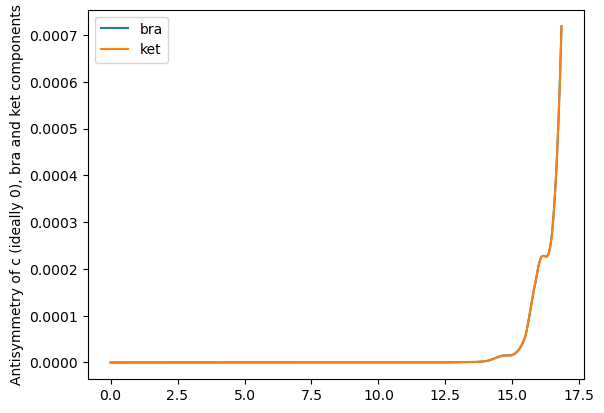

' checking if need the antisymmetrisation of rhorho based on this formalism. YOU DO '

In [15]:
"""
Check c is antisymmetric
"""
def check_c2_antisymmetry(c2):
    bra_error=[]
    ket_error=[]
    for t in range(len(soln.t)):
        bra_error.append(np.max(np.abs(c2[:,:,:,:,t] + c2[:,:,:,:,t].swapaxes(0, 1))))
        ket_error.append(np.max(np.abs(c2[:,:,:,:,t] + c2[:,:,:,:,t].swapaxes(2, 3))))
    return np.array(bra_error), np.array(ket_error)

c4 = c_soln.reshape(2*P, 2*P, 2*P, 2*P, len(soln.t))
bra_err, ket_err = check_c2_antisymmetry(c4)

plt.plot(soln.t,bra_err,label='bra')
plt.plot(soln.t,ket_err,label='ket')
plt.ylabel('Antisymmetry of c (ideally 0), bra and ket components')
plt.legend()
plt.show()


''' checking if need the antisymmetrisation of rhorho based on this formalism. YOU DO '''
# rho2_notantisym = rhorho_soln+c_soln.reshape(2*P, 2*P, 2*P, 2*P, len(soln.t))
# bra_err, ket_err = check_c2_antisymmetry(rho2_notantisym)

# plt.plot(soln.t,bra_err,label='bra')
# plt.plot(soln.t,ket_err,label='ket')
# plt.ylabel('Antisymmetry of rhorho+c2 (ideally 0), bra and ket components')
# plt.legend()
# plt.show()

c:\Users\annas\anaconda3\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\annas\anaconda3\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


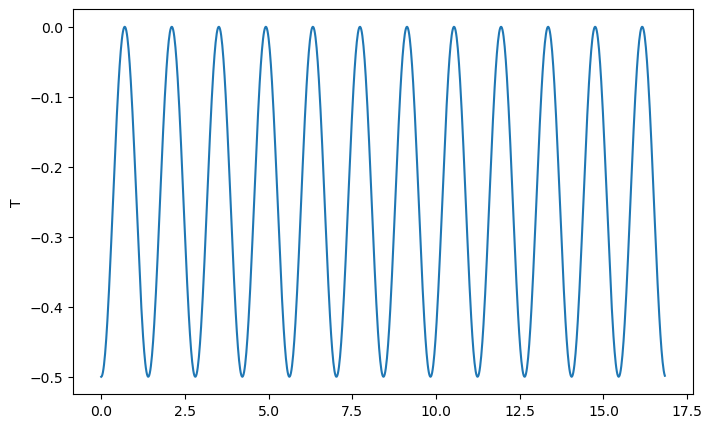

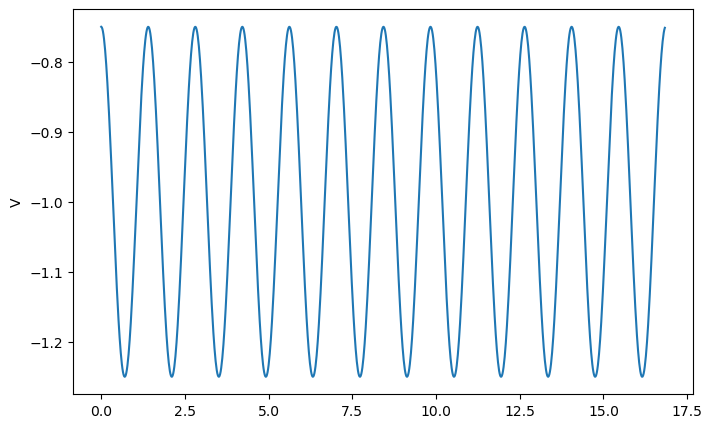

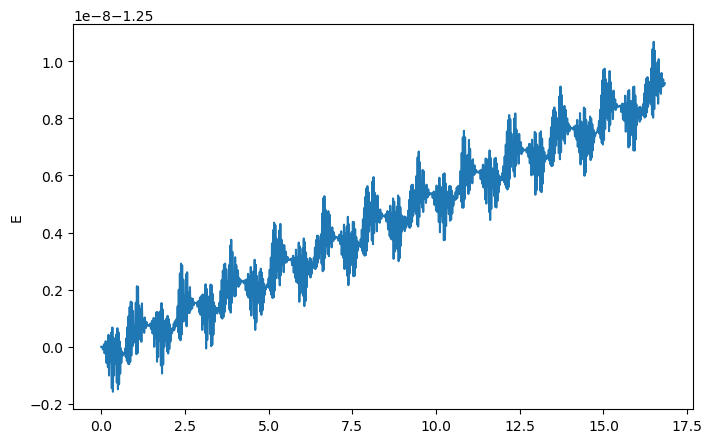

In [16]:
"""
Check energy conservation
"""
# print(Hh0())
# print(Hv())

# kinetic (1body) and potential (2body) energies
Ttot = np.einsum("ijt,ji->t",rho_soln,Hh0(), optimize=True)
# Based on H in paper, there is 1/2 outside the V term
Vtot = 0.5*np.einsum("ijklt,klij->t",rho2_soln.reshape(2*P,2*P,2*P,2*P,-1),Hv(), optimize=True)
Etot = Ttot + Vtot

plt.figure(figsize=(8,5))
plt.plot(soln.t,Ttot)
plt.ylabel('T')
plt.show()
plt.figure(figsize=(8,5))
plt.plot(soln.t,Vtot)
plt.ylabel('V')
plt.show()

plt.figure(figsize=(8,5))
plt.plot(soln.t,Etot)
plt.ylabel('E')
plt.show()

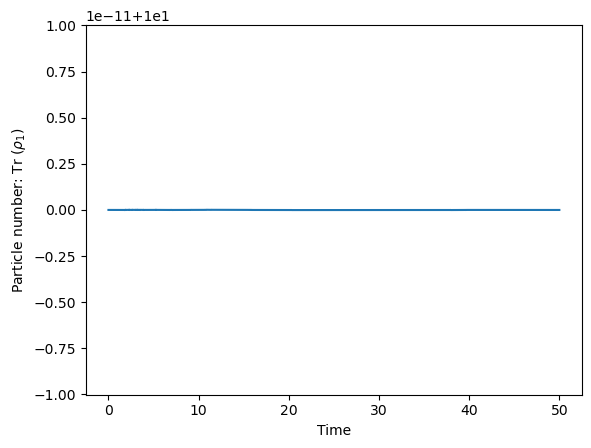

In [40]:
"""
particle number should be conserved
"""

plt.plot(soln.t,np.trace(rho_soln,axis1=0,axis2=1))
# plt.ylim(0,4)
plt.ylabel(r'Particle number: Tr $(\rho_1)$')
plt.xlabel('Time')
plt.show()

In [ ]:
"""
Check number of particles in the bottom 
"""
# mean, var, residual = lower_occupation(rho_soln, c_soln.reshape(2*P,2*P,2*P,2*P,-1), N=None)
# plt.plot(soln.t,mean)
# plt.show()


# plt.plot(soln.t,Ndown(rho_soln),label='bottom level')
# plt.plot(soln.t,Nup(rho_soln),label='top level')
# plt.legend()
# plt.show()

# # check how much of the state is in the HF stationary points 
# print(HFstat(rho_soln,np.arccos(eps/(V*P-V)),0)[0])
# print(HFstat(rho_soln,np.arccos(eps/(V*P-V)),np.pi)[0])
# print('') # this is the tdhf initial and constant 

# plt.plot(soln.t,HFstat(rho_soln,np.arccos(eps/(V*P-V)),0),label='min1')
# plt.plot(soln.t,HFstat(rho_soln,np.arccos(eps/(V*P-V)),np.pi),label='min2')
# plt.plot(soln.t,HFstat(rho_soln,np.arccos(eps/(V*P-V)),0)+HFstat(rho_soln,np.arccos(eps/(V*P-V)),np.pi),label='sum') # they clearly have some overlap, bc >3
# plt.legend()
# plt.show()

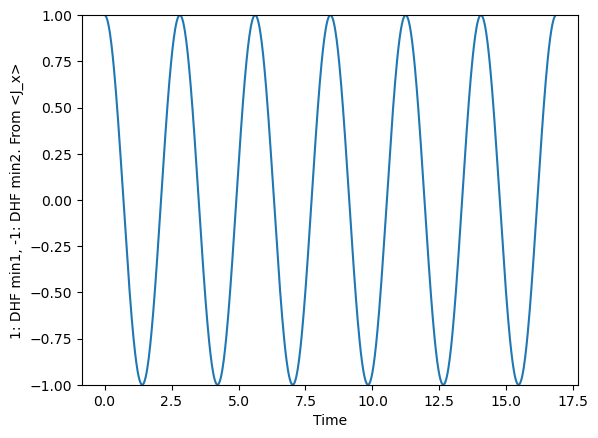

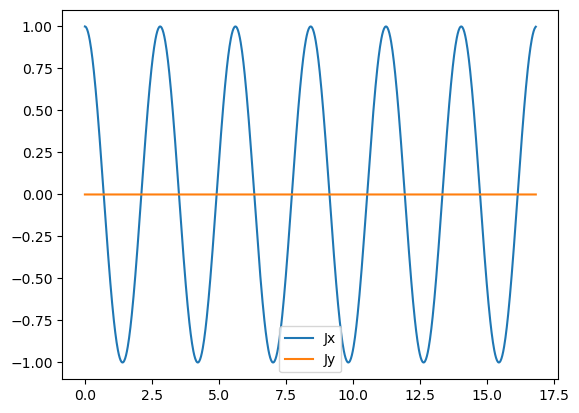

In [17]:
''' J observables for TDDM 
same result for rho_soln and Tr(rho2_soln)'''
# DHF minima are at <J_x> = sign*P/2*sin(2a)

Jx, Jy, Jz = Jobservables(rho_soln)
Jdhfmin_tddm = Jx/(0.5*P*np.sin(2*a_dhf))
plt.plot(soln.t,Jdhfmin_tddm)
plt.ylabel('1: DHF min1, -1: DHF min2. From <J_x>')
plt.xlabel('Time')
plt.ylim(-1,1)
# plt.xlim(0,5)
plt.show()


# Jx, Jy, Jz = Jobservables(red1body_tddm)
# Jdhfmin_tddm2bod = Jx/(0.5*P*np.sin(2*a_dhf))
# plt.plot(soln.t,Jdhfmin_tddm2bod)
# plt.ylabel('1: DHF min1, -1: DHF min2. From <J_x>')
# plt.xlabel('Time')
# # plt.ylim(-1,1)
# # plt.xlim(0,5)
# plt.show()

plt.plot(soln.t,Jx/(0.5*P*np.sin(2*a_dhf)),label='Jx')
plt.plot(soln.t,Jy/(0.5*P*np.sin(2*a_dhf)),label='Jy')
# plt.plot(soln.t,np.real((Jx+1j*Jy)/(0.5*P*np.sin(2*a_dhf))),label='sum')
plt.legend()
plt.show()
# print(Jy[-1]/(0.5*P*np.sin(2*a_dhf)))

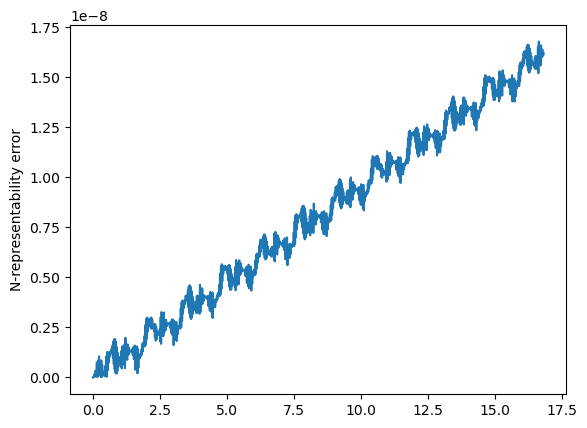

In [18]:
''' N-representability - difference in 1body rho and reduced 1body from 2body rho'''

red1body_tddm = 1/(P-1)*np.einsum('ijkjt->ikt',rho2_soln.reshape(2*P,2*P,2*P,2*P,-1))
err_Nrep = np.array([ np.max(np.abs(red1body_tddm[:,:,t] - rho_soln[:,:,t])) for t, time in enumerate(soln.t)])
plt.plot(soln.t,err_Nrep)
plt.ylabel('N-representability error')
plt.show()


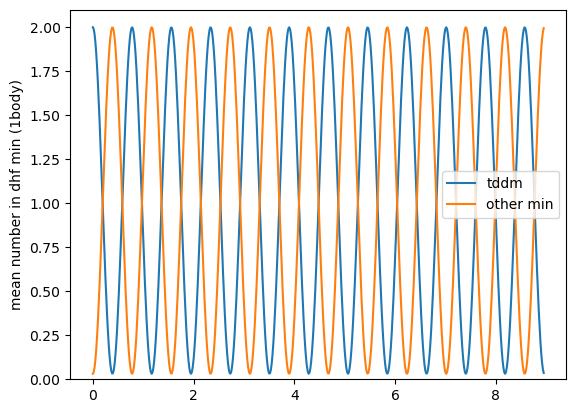

In [53]:
nDHFmin_tddm = DHFobservable(a_dhf,rho_soln)

plt.plot(soln.t,nDHFmin_tddm,label='tddm')
plt.plot(soln.t,DHFobservable(-a_dhf,rho_soln),label='other min')
plt.ylabel('mean number in dhf min (1body)')
plt.ylim(0,P+0.1)
plt.legend()
plt.show()

In [53]:
# print(c_soln[:,:,0])
# print(c_soln[:,:,50])
# print(c_soln[:,:,-1])
print(np.max(c_soln))

(0.33210175358579314+0.001532216057424313j)


c:\Users\annas\anaconda3\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\annas\anaconda3\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


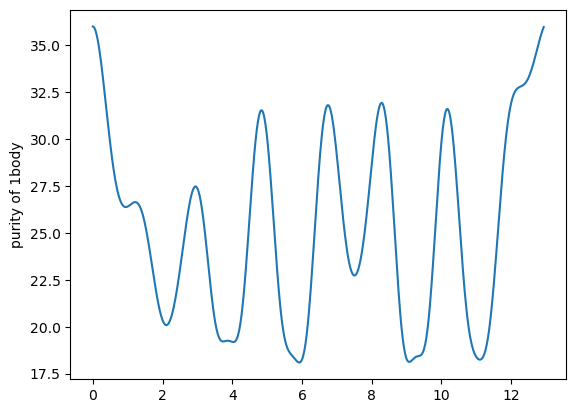

(0.9999999999999999+0j)
(23.999999999999996+0j)


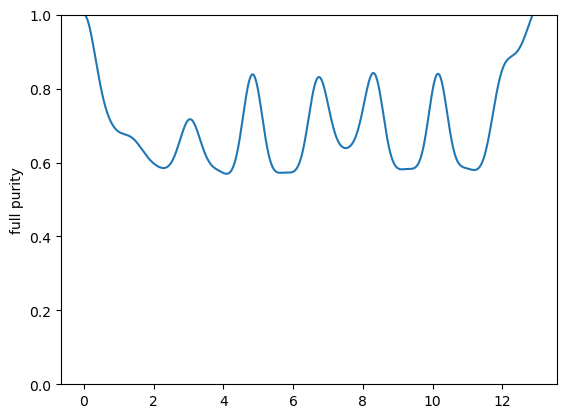

In [ ]:
"""
Check purity of 1body ENTANGLEMENT 
"""
reduced1body = np.einsum('ijkjt->ikt',rho2_soln.reshape(2*P,2*P,2*P,2*P,-1), optimize=True)
purity = np.einsum('ikt,kit->t',reduced1body,reduced1body, optimize=True)
plt.plot(soln.t,purity)
plt.ylabel('purity of 1body')
plt.show()

# peaks, _ = find_peaks(purity.real)
# purpeak = np.array(purity.real[peaks])
# print('peak heights:',purpeak)
# purpeakt = soln.t[peaks]
# print('purity peaks at t:',purpeakt)

''' 
check purity of full state: Tr(rho2^2)
IT BECOMES A MIXED STATE GUYSSSS
'''
print(np.trace(rho2_soln[:,:,0]/12))
print(np.trace(rho2_soln[:,:,0]@rho2_soln[:,:,0]))
purityfull = np.einsum('ijt,jit->t',rho2_soln,rho2_soln)/24
plt.plot(soln.t,purityfull)
plt.ylabel('full purity')
plt.ylim(0,1)
plt.show()

In [55]:
"""
Check if the density matrix stays hermitian
"""
print('These should be 0:')
dI2 = rho2_soln - rho2_soln.conj().transpose(1,0,2)
print(dI2.real.max())
print(dI2.imag.max())

dI1 = rho_soln - rho_soln.conj().transpose(1,0,2)
print(dI1.real.max())
print(dI1.imag.max())

These should be 0:
0.0002460101023740169
0.0004950404621630462
7.989714668395209e-05
8.627563520553105e-05


## Lipkin exact evolution ##

In [22]:
def trdickeMINE(rhoin,mbodyout):
    # for rhoin NOT TIME DEP
    
    # rhoin = sum_k,j coeff_k,j |N,k><N,j| 
    N = (rhoin.shape[0]-1) # Nbody rho input, so k,j go from 0 to N
    m = mbodyout
    ntr = N-m # this is how many particles we trace over 
    
    rhom = np.zeros((m+1,m+1),dtype=complex)
    
    for k in range(N+1): # k,j from 0 to N, there are N+1 of these values 
        for j in range(N+1):
            c_kj = rhoin[k,j] # k & j can be zero and this corresp to zero particles in upper level, good. 
            if c_kj <1e-10 : continue
            
            for a in range(ntr+1): # so we actually get to the number ntr
                if (k-a)<0 or (k-a)>m: continue
                if (j-a)<0 or (j-a)>m: continue 
                rhomterm = comb(ntr,a)*np.sqrt(comb(m,k-a)*comb(m,j-a)) 
                rhom[k-a,j-a] += [rhomterm if rhomterm>1e-10 else 0.0]
            rhom *= 1/np.sqrt(comb(N,k)*comb(N,j))
            rhom *= c_kj
    rhom[np.abs(rhom) < 1e-10] = 0.0
    return rhom * fact(N)/fact(N-m)


def trdicke(rhoin, mbodyout):
    """Partial trace of a Dicke-basis density matrix, N-body -> m-body.
    rhoin : (N+1, N+1), or (N+1, N+1, T) with a trailing time axis.
    Trace-preserving."""
    rhoin = np.asarray(rhoin)
    N, m = rhoin.shape[0] - 1, mbodyout
    if not 0 <= m <= N:
        raise ValueError(f'need 0 <= mbodyout <= {N}, got {m}')
    ntr  = N - m
    tail = (1,)*(rhoin.ndim - 2)          # remaining axes of the array
    bN   = np.array([comb(N,k) for k in range(N+1)], float)
    bm   = np.array([comb(m,p) for p in range(m+1)], float)

    W    = rhoin / np.sqrt(np.outer(bN,bN)).reshape(N+1, N+1, *tail) # divide each element kj of rhoin by sqrt (NCk NCj)
    rhom = np.zeros((m+1, m+1) + rhoin.shape[2:], dtype=complex)
    for a in range(ntr+1):
        rhom += comb(ntr,a) * W[a:a+m+1, a:a+m+1] # W is rhoin*coeff. indices such that only use 0 <= k-a <= m
    rhom *= np.sqrt(np.outer(bm,bm)).reshape(m+1, m+1, *tail) # sqrt coeff numerator in sum
    rhom *= fact(N)/fact(N-m) # so that scaling is same as reduced densities throughout 
    return rhom 


def trdicke_psi(psi, mbodyout):
    """Same, straight from a state vector. psi is (N+1,) or (N+1, T) with time LAST.
    Skips building the (N+1, N+1, T) outer product."""
    psi = np.asarray(psi)
    N, m = psi.shape[0] - 1, mbodyout
    if not 0 <= m <= N:
        raise ValueError(f'need 0 <= mbodyout <= {N}, got {m}')
    ntr  = N - m
    tail = (1,)*(psi.ndim - 1)
    bN   = np.array([comb(N,k) for k in range(N+1)], float)
    bm   = np.array([comb(m,p) for p in range(m+1)], float)

    phi  = psi / np.sqrt(bN).reshape(N+1, *tail)
    rhom = np.zeros((m+1, m+1) + psi.shape[1:], dtype=complex)
    for a in range(ntr+1):
        blk = phi[a:a+m+1]
        rhom += comb(ntr,a) * np.einsum('p...,q...->pq...', blk, blk.conj())
    rhom *= np.sqrt(np.outer(bm,bm)).reshape(m+1, m+1, *tail)
    rhom *= fact(N)/fact(N-m)
    return rhom 

def Jobservables_dicke(rho1):
    assert rho1.shape[:2] == (2,2)
    Jp = rho1[0,1] # <J_+>
    Jz = 0.5*(rho1[1,1] - rho1[0,0])
    return Jp.real, Jp.imag, Jz.real    # <J_x>, <J_y>, <J_z>

def DHFobservable_dicke(a,n):
    assert n.shape[:2] == (2,2)
    mean = ( np.cos(a)**2 *n[0,0]
            + np.sin(a)**2 *n[1,1]
            + np.sin(a)*np.cos(a)*(n[0,1] + n[1,0]) )
    return mean


### starts here ###

In [56]:
''' t_list already exists, use same one '''
# t_list=np.linspace(0.0,25.0,2001)
t_list = np.linspace(soln.t[0],soln.t[-1],len(soln.t))

# interaction is +V/2, matching H = eps*Jz + V/2 (J+^2 + J-^2) and Hv()
def Hdicke():
    Hdicke = np.zeros((P+1,P+1),dtype=complex)
    for k in range(P+1):
        Hdicke[k,k] = eps*(k-P/2)
    for k in range(2,P+1):
        Hdicke[k-2,k] = +V/2 *np.sqrt(k*(P-k+1)*(k-1)*(P-k+2))
    for k in range(P-1):
        Hdicke[k+2,k] = +V/2 *np.sqrt((P-k)*(k+1)*(P-k-1)*(k+2))
    return Hdicke

def h0dicke():
    h0dicke = np.zeros((P+1,P+1),dtype=complex)
    for k in range(P+1):
        h0dicke[k,k] = eps*(k-P/2)
    return h0dicke

def vdicke():
    vdicke = np.zeros((P+1,P+1),dtype=complex)
    for k in range(2,P+1):
        vdicke[k-2,k] = +V/2 *np.sqrt(k*(P-k+1)*(k-1)*(P-k+2))
    for k in range(P-1):
        vdicke[k+2,k] = +V/2 *np.sqrt((P-k)*(k+1)*(P-k-1)*(k+2))
    return vdicke


''' Start in the DHF minimum, to match the TDDM initial condition.

The DHF Slater  prod_p ( cos(a) c+_-p + sin(a) c+_p ) |0>  is an SU(2) coherent state, so it
lies entirely inside the (P+1)-dim symmetric Dicke subspace -- no component is lost by working
in this basis. Expanding the product and grouping the 2^P terms by k = number of particles in
the upper level gives
    <k|DHF> = sqrt( C(P,k) ) cos(a)^(P-k) sin(a)^k ,     cos(2a) = 1/chi
which is already normalised, since sum_k C(P,k) cos^2(P-k) sin^2k = (cos^2+sin^2)^P = 1.
Checked against the full 2^(2P) Fock-space Slater: overlaps agree to 1e-16 and the state has
zero weight outside the Dicke subspace.

sign=+1 and sign=-1 pick the two degenerate minima (the phi=0 and phi=pi ones).
'''
def psi_DHF_dicke(sign=+1):
    chi_pos = np.abs(V)*(P-1)/eps      # POSITIVE chi, as in n_DHF -- not the signed one
    if chi_pos <= 1:
        raise AttributeError('chi<1, no deformed minimum')
    a = 0.5*np.arccos(1.0/chi_pos) # alpha value at the HF minima: is +/- this number for the 2 minima
    c, s = np.cos(a), sign*np.sin(a) # sign=+ is one minimum, - is the other
    return np.array([np.sqrt(comb(P,k)) * c**(P-k) * s**k for k in range(P+1)], dtype=complex)

def LipkinDicke(psiin,t_list,evals,Pdicke):
    # project psiin onto the eigenstates of Hdicke: psiin = a_n |n> so a_n = <n|psiin>
    # H = P D P^-1 so D has e'vals and P colums are evecs
    an = np.einsum('ij,j->i', Pdicke.T.conj(), psiin) # transpose!!!  so rows of Pdicke.T are evecs 
    psiout = np.zeros((P+1,len(t_list)), dtype=complex)
    for t, time in enumerate(t_list):
        for k in range(P+1):
            psiout[:,t] += an[k]*np.exp(-1j*evals[k]*time)*Pdicke[:,k] # note the +=, we are adding up Sum_n a_n exp(-i E_n t) |n> for each timestep
    return psiout # each column is psiout for a particular time 


# diagonalise
# H = P D P^-1
evals, Pdicke = np.linalg.eig(Hdicke()) # Pdicke has eigenvectors as columns ie first evec is Pdicke[:,0] 
Ddicke = np.diag(evals)

'''start all in bottom'''
# psiin = np.zeros(P+1,dtype=complex)
# psiin[0] = 1.0 # ie full occupation in bottom level, zero in top level so k=0
'''start all in dhf min'''
psiin = psi_DHF_dicke(+1)

assert np.isclose(np.linalg.norm(psiin), 1.0)

''' Now evolve! '''
psiout_exact = LipkinDicke(psiin,t_list,evals,Pdicke)
print(psiout_exact.shape)

exact1body = trdicke_psi(psiout_exact,1)
print(exact1body.shape)

(3, 538)
(2, 2, 538)


(2, 2, 3001)


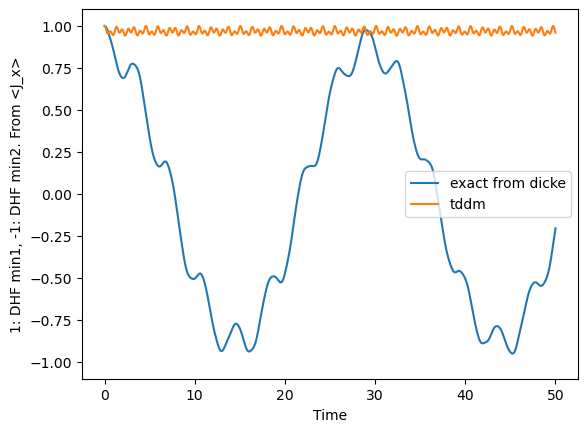

In [ ]:
''' Check J observables
For physical states, <Jx> <= J=P/2 and |Jdhfmin| <= 1/sin(2a)=1.15'''


# print(np.einsum('iit->t',exact1body)) # fab this is always =P

Jx_exact, Jy_exact, Jz_exact = Jobservables_dicke(exact1body)
Jdhfmin_exact = Jx_exact/(0.5*P*np.sin(2*a_dhf))

plt.plot(t_list,Jdhfmin_exact,label='exact from dicke')
plt.plot(soln.t,Jdhfmin_tddm,label='tddm')
# plt.plot(soln_tdhf.t,Jdhfmin_tdhf,label='tdhf')
plt.ylabel('1: DHF min1, -1: DHF min2. From <J_x>')
plt.xlabel('Time')
plt.ylim(-1.1,1.1)
# plt.xlim(0,10)
plt.legend()
plt.show()
# print(Jdhfmin_exact[0])

(0.031253466032481025+0j)


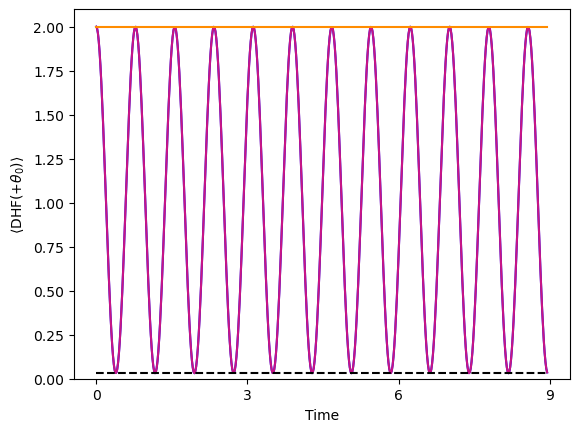

In [ ]:
nDHFmin_exact = DHFobservable_dicke(a_dhf,exact1body)
# plt.plot(t_list,nDHFmin_exact,'b',label='Exact')
# plt.plot(soln.t,nDHFmin_tddm,color='mediumvioletred',label='TDDM')
# plt.plot(t_list,nDHFmin_tdhf,color='darkorange',label='TDHF')
# plt.ylim(0,P+0.1)
# plt.xlim(-0.07,2.1)
# # plt.ylabel('Mean number in DHF minimum (1body)')
# plt.ylabel(rf'$\langle \mathrm{{DHF}}(+\theta_0)\rangle$')
# plt.xlabel('Time')
# # plt.xaxis.set_major_locator(ticker.MultipleLocator(0.5))
# plt.legend()
# # plt.savefig(f'C:/Users/annas/Documents/2026/Honours/Thesis/Figures/TDDM/nDHFmin_N{P}_chi{chi}_V{V}.eps',bbox_inches='tight',dpi=300)
# plt.show()
print(nDHFmin_exact.min())

fig, ax = plt.subplots()
ax.plot(t_list,nDHFmin_exact,'b',label='Exact')
ax.plot(soln.t,nDHFmin_tddm,color='mediumvioletred',label='TDDM')
ax.plot(soln_tdhf.t,nDHFmin_tdhf,color='darkorange',label='TDHF')
plt.hlines(y=P/chi**2,xmin=0,xmax=t_list[-1],color='k',linestyles='--')
ax.set_ylim(0,P+0.1)
# ax.set_xlim(None,50.5)
# plt.ylabel('Mean number in DHF minimum (1body)')
ax.set_ylabel(rf'$\langle \mathrm{{DHF}}(+\theta_0)\rangle$')
ax.set_xlabel('Time')
ax.xaxis.set_major_locator(ticker.MultipleLocator(3))
# ax.legend(loc=1)
# ax.legend()
# plt.savefig(f'C:/Users/annas/Documents/2026/Honours/Thesis/Figures/TDDM_figures/tddm_nDHFmin_N{P}_chi{chi}_V{V}.eps',bbox_inches='tight',dpi=300)
plt.show()

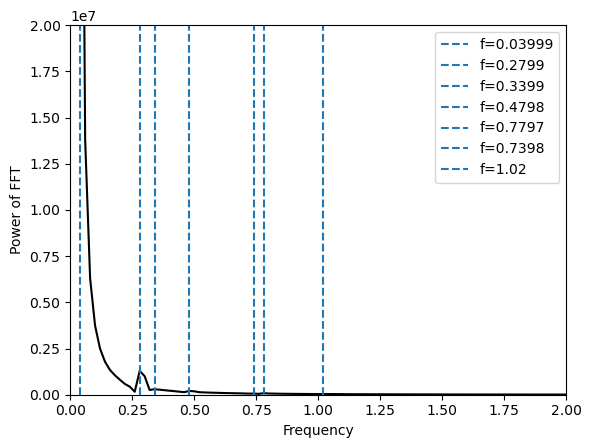

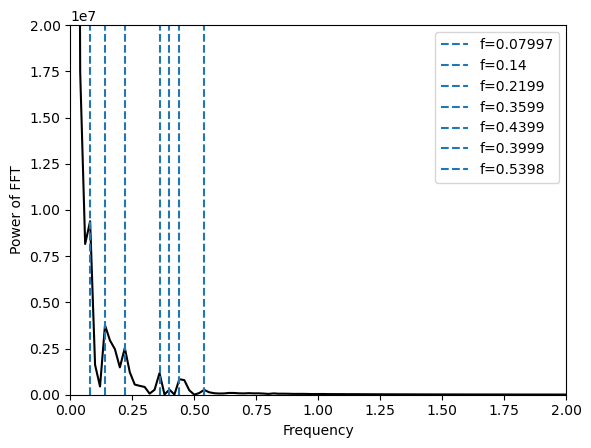

(array([0.07997334, 0.13995335, 0.21992669, 0.35988004, 0.43985338,
        0.39986671, 0.53982006, 0.63978674, 0.71976008, 0.75974675,
        0.81972676, 0.85971343, 0.93968677, 1.01966011, 1.07964012,
        1.13962013, 1.35954682, 1.43952016]),
 array([9387499.94692198, 3760075.8989695 , 2530925.57462354,
        1171739.7210773 ,  839163.11190412,  273538.62564559,
         261256.78477404,   96019.71320361,   84351.10069664,
          75289.54628181,   71594.36934802,   55760.23558901,
          45958.00328016,   38698.35366256,   32530.60608758,
          29745.54096697,   20561.58819721,   18009.99112809]))

In [98]:
''' Check frequency of oscillations in exact vs tddm'''

# fourier(t_list,signal,xlim,ylim,numberpeaks)
fourier_funcs.fourier(soln.t,nDHFmin_exact,[0,2],[0,0.2e8],7)
fourier_funcs.fourier(soln.t,nDHFmin_tddm,[0,2],[0,0.2e8],7)

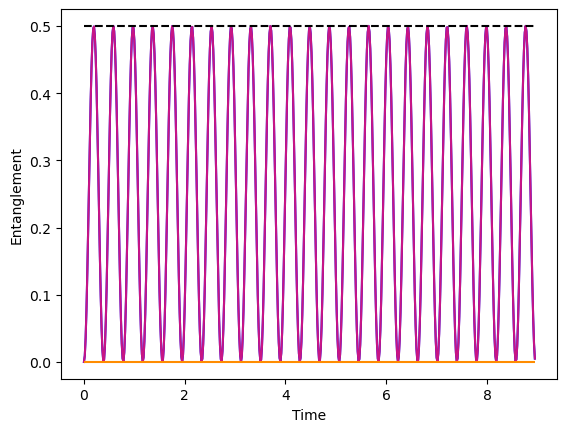

In [ ]:
''' Check entanglement of these solutions '''

tddm1body = 1/(P-1)*np.einsum('ijkjt->ikt',rho2_soln.reshape((2*P,)*4 + (-1,)))
# print(np.trace(tddm1body[:,:,0])) # =P
# print(np.trace(rho_soln[:,:,0])) # =P
# print(np.trace(rho2_soln[:,:,0])) # =P(P-1)
# print(np.trace(exact1body[:,:,0])) # =P

# now trace over the p degenerate orbitals, get dicke form 
tddm1body_dicke = np.einsum('spqpt->sqt', tddm1body.reshape(2, P, 2, P, -1))
purity_tddm = np.einsum('ijt,jit->t',1/P*tddm1body_dicke,1/P*tddm1body_dicke)


purity_exact = np.einsum('ijt,jit->t',1/P*exact1body,1/P*exact1body)

# tdhf1body_dicke = np.einsum('spqpt->sqt', rho_soln_tdhf.reshape(2, P, 2, P, -1))
# purity_tdhf = np.einsum('ijt,jit->t',1/P*tdhf1body_dicke,1/P*tdhf1body_dicke)

plt.plot(t_list,1-purity_exact,'b',label='Exact')
plt.plot(soln.t,1-purity_tddm,color='mediumvioletred',label='TDDM')
plt.hlines(y=0, xmin=0, xmax=t_list[-1],color='darkorange',label='TDHF')
plt.hlines(y=(1/2), xmin=0, xmax=t_list[-1],color='k',linestyles='--')
# plt.plot(t_list,1-purity_tdhf,label='tdhf')
plt.ylabel('Entanglement')
plt.xlabel('Time')
# plt.xlim(None,50.5)
# plt.legend(loc=1)
# plt.savefig(f'C:/Users/annas/Documents/2026/Honours/Thesis/Figures/TDDM_figures/entangleTDDM_N{P}_chi{chi}_V{V}.eps',bbox_inches='tight',dpi=300)
plt.show()


(3, 130)
(4, 4)
(4, 4, 130)
(130,)


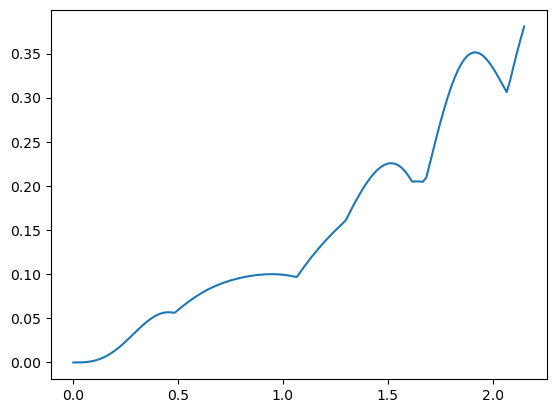

In [ ]:
''' 
Testing whether N=2 gives exact solution in TDDM
It doesnt :(((((((
'''

print(psiout_exact.shape)
# print(psiout_exact[0,:])

low1 = np.array([1,0,0,0],dtype=complex)
low2 = np.array([0,1,0,0],dtype=complex)
up1 = np.array([0,0,1,0],dtype=complex)
up2 = np.array([0,0,0,1],dtype=complex)

def asym2(x, y):
    """normalised antisymmetrised 2-particle state (x⊗y - y⊗x)/sqrt(2), shape (2P, 2P)"""
    return (np.einsum('i,j->ij', x, y) - np.einsum('i,j->ji', x, y))/np.sqrt(2)

dicke20 = asym2(low1, low2)
dicke21 = (asym2(low1, up2) + asym2(up1, low2))/np.sqrt(2)
dicke22 = asym2(up1, up2)
print(dicke21.shape)   # (4, 4)

psiout_exact_full = ( np.einsum('t,pq->pqt', psiout_exact[0,:], dicke20)
                    + np.einsum('t,pq->pqt', psiout_exact[1,:], dicke21)
                    + np.einsum('t,pq->pqt', psiout_exact[2,:], dicke22) )
print(psiout_exact_full.shape)   # (4, 4, T)

rho2_exact_full = 2*np.einsum('abt,cdt->abcdt', psiout_exact_full, psiout_exact_full.conj())  # N(N-1)|psi><psi|
rho1_exact_full    = 2*np.einsum('abt,cbt->act',   psiout_exact_full, psiout_exact_full.conj())  # N Tr_2|psi><psi|

difference2body = np.array([ np.abs(rho2_exact_full[:,:,:,:,t]-rho2_soln.reshape(4,4,4,4,-1)[:,:,:,:,t]).max() for t in range(len(soln.t))]) #.transpose(1,2,3,4,0)
print(difference2body.shape)
plt.plot(soln.t,difference2body)
plt.show()

In [ ]:
''' Exact evolution NOT IN DICKE BASIS '''

# t_list=np.linspace(0.0,5.0,501)

# # all in bottom level
# assert P==3
# # p1 = np.array([1,0,0,0,0,0],dtype=complex)
# # p2 = np.array([0,1,0,0,0,0],dtype=complex)
# # p3 = np.array([0,0,1,0,0,0],dtype=complex)

# # tdhf minimum 1
# chi = (P-1)*V/eps
# th = np.arccos(1/chi)
# phi = 0
# p1 = np.array([np.cos(th/2),0,0,np.exp(-1j*phi)*np.sin(th/2),0,0],dtype=complex)
# p2 = np.array([0,np.cos(th/2),0,0,np.exp(-1j*phi)*np.sin(th/2),0],dtype=complex)
# p3 = np.array([0,0,np.cos(th/2),0,0,np.exp(-1j*phi)*np.sin(th/2)],dtype=complex)

# psiin = np.einsum('i,j,k->ijk',p1,p2,p3)
# apsiin = 1/np.sqrt(6)*( psiin 
#           -np.einsum('ijk->ikj',psiin)
#           -np.einsum('ijk->jik',psiin)
#           +np.einsum('ijk->jki',psiin)
#           +np.einsum('ijk->kij',psiin)
#           -np.einsum('ijk->kji',psiin)
#          )
# Din = np.einsum('ijk,lmn->ijklmn',apsiin,apsiin.conj() )
# Din = Din.reshape(8*P**3,8*P**3)
# print(Din.shape)

# I2P = np.eye(2*P,dtype=complex)
# H = ( np.einsum('il,jm,kn->ijklmn',Hh0(),I2P,I2P) 
#      +np.einsum('ijlm,kn->ijklmn',Hv().reshape(2*P,2*P,2*P,2*P),I2P)    )
# H = H.reshape(8*P**3,8*P**3)
# Dout = []
# for t in t_list:
#     Dout.append( expm(-1j*H*t) @ Din @ expm(1j*H*t) )
#     # print(( expm(-1j*H*t) @ Din @ expm(1j*H*t) ).shape)
# Dout = np.array(Dout)
# Dout = np.moveaxis(Dout,0,-1)
# print(Dout.shape)

In [ ]:
# """
# Check number of particles in the bottom 
# """
# rho_exact = 3*np.einsum( 'ijkljkt->ilt', Dout.reshape(2*P,2*P,2*P,2*P,2*P,2*P,len(t_list)) )
# plt.figure(figsize=(8,4))
# plt.plot(t_list,Ndown(rho_exact),label='Exact',color='mediumvioletred')
# plt.plot(soln.t,Ndown(rho_soln),label='TDDM',color='darkorange')
# plt.plot(soln.t,Ndown(rho_soln_tdhf),'b',label='Mean-field')
# plt.legend(loc=4,fontsize=11)
# plt.ylim(0,3.1)
# plt.xlabel('Time',fontsize=11)
# plt.ylabel(r'$\langle$Number in bottom$\rangle$',fontsize=11)
# # plt.savefig(f'C:/Users/annas/Documents/2026/Honours/Entangle_Magic/lipkin_allHFmin1_Nbot.png',bbox_inches='tight',dpi=300)
# plt.show()


# ''' Check how much of the state is in the HF stationary points '''
# plt.figure(figsize=(8,4))
# plt.plot(t_list,HFstat(rho_exact,np.arccos(eps/(V*P-V)),0),label='Exact',color='mediumvioletred')
# plt.plot(soln.t,HFstat(rho_soln,np.arccos(eps/(V*P-V)),0),label='TDDM',color='darkorange')
# plt.plot(soln_tdhf.t,HFstat(rho_soln_tdhf,np.arccos(eps/(V*P-V)),0),'b',label='Mean-field')
# plt.ylabel(r'$\langle$Number in HF ground 1$\rangle$',fontsize=11)
# plt.xlabel('Time',fontsize=11)
# plt.ylim(0,3.1)
# plt.legend(loc=4,fontsize=11)
# # plt.savefig(f'C:/Users/annas/Documents/2026/Honours/Entangle_Magic/lipkin_allHFmin1_Nmin1.png',bbox_inches='tight',dpi=300)
# plt.show()

# plt.figure(figsize=(8,4))
# plt.plot(t_list,HFstat(rho_exact,np.arccos(eps/(V*P-V)),np.pi),'--',label='Exact',color='mediumvioletred')
# plt.plot(soln.t,HFstat(rho_soln,np.arccos(eps/(V*P-V)),np.pi),'--',label='TDDM',color='darkorange')
# plt.plot(soln_tdhf.t,HFstat(rho_soln_tdhf,np.arccos(eps/(V*P-V)),np.pi),'b--',label='Mean-field')
# plt.ylabel(r'$\langle$Number in HF ground 2$\rangle$',fontsize=11)
# plt.xlabel('Time',fontsize=11)
# plt.ylim(0,3.1)
# plt.legend(loc=4,fontsize=11)
# # plt.savefig(f'C:/Users/annas/Documents/2026/Honours/Entangle_Magic/lipkin_allHFmin1_Nmin2.png',bbox_inches='tight',dpi=300)
# plt.show()

In [ ]:
# ''' 
# Check entanglement of these solutions 

# FIX THE NORMALISATION 
# '''

# epower_soln = Epower_funcs.Epower_rho(rho_soln,P)/3
# epower_exact = Epower_funcs.Epower_rho(rho_exact,P)/3
# epower_soln_tdhf = Epower_funcs.Epower_rho(rho_soln_tdhf,P)/3

# plt.figure(figsize=(8,4))
# plt.plot(soln.t,epower_exact,label='Exact',color='mediumvioletred')
# plt.plot(soln.t,epower_soln,label='TDDM',color='darkorange')
# plt.plot(soln.t,epower_soln_tdhf,'b',label='Mean-field')
# plt.ylabel(r'Entanglement',fontsize=11)
# plt.xlabel('Time',fontsize=11)
# plt.legend(loc=1,fontsize=11)
# plt.ylim(-0.03,None)
# # plt.savefig(f'C:/Users/annas/Documents/2026/Honours/Entangle_Magic/lipkin_allHFmin1_entangle.png',bbox_inches='tight',dpi=300)
# plt.show()

## TDHF calc ##

In [57]:
"""
Initial conditions
"""

"""
If rho0 is diagonal then we get a stationary solution of TDHF!!!

Slightly rotate the single-particle basis states
Then make a slater, and the corresp 1body rho
"""

# arbitrary non-stationary state
# de = 0.01
# ps = np.zeros((P,2*P),dtype=complex)
# for p in range(1,P):
#     ps[0,0] = np.cos(de)
#     ps[0,P] = np.sin(de)
#     ps[p,p] = 1
# # for a Slater:
# rho0 = np.zeros((2*P,2*P),dtype=complex)
# for p in range(P):
#     rho0 += np.outer(ps[p,:],ps[p,:].conj())

rho0 = n_DHF(+1)


assert np.allclose(rho0@rho0,rho0)
assert np.allclose(np.trace(rho0),P)

y0 = rho0.ravel()

"""
Consistency checks for integration
""" 
assert rho0.shape == (2*P,2*P)
assert y0.shape == (4*P**2,)

# Evaluate the RHS once to catch indexing errors.
test_derivative = TDHF(t=0.0,y=y0)
assert test_derivative.shape == y0.shape
assert np.all(np.isfinite(test_derivative))

print('P =',P)
print("Initial state shape y0:", y0.shape)
print("Initial derivative shape:", test_derivative.shape)

P = 2
Initial state shape y0: (16,)
Initial derivative shape: (16,)


In [63]:
''' Test initial derivative of rho, ie will it evolve? '''

drho0 = TDHF(0.0, rho0.ravel()).reshape(2*P, 2*P)
print("Maximum |drho/dt|:", np.max(np.abs(drho0)))
print("Frobenius norm of drho/dt:", np.linalg.norm(drho0))
print("drho/dt:")
print(np.round(drho0, 12))

Maximum |drho/dt|: 5.551115123125783e-17
Frobenius norm of drho/dt: 1.5700924586837752e-16
drho/dt:
[[0.-0.j 0.-0.j 0.-0.j 0.-0.j 0.+0.j 0.-0.j 0.-0.j 0.-0.j]
 [0.-0.j 0.-0.j 0.-0.j 0.-0.j 0.-0.j 0.+0.j 0.-0.j 0.-0.j]
 [0.-0.j 0.-0.j 0.-0.j 0.-0.j 0.-0.j 0.-0.j 0.+0.j 0.-0.j]
 [0.-0.j 0.-0.j 0.-0.j 0.-0.j 0.-0.j 0.-0.j 0.-0.j 0.+0.j]
 [0.-0.j 0.-0.j 0.-0.j 0.-0.j 0.-0.j 0.-0.j 0.-0.j 0.-0.j]
 [0.-0.j 0.-0.j 0.-0.j 0.-0.j 0.-0.j 0.-0.j 0.-0.j 0.-0.j]
 [0.-0.j 0.-0.j 0.-0.j 0.-0.j 0.-0.j 0.-0.j 0.-0.j 0.-0.j]
 [0.-0.j 0.-0.j 0.-0.j 0.-0.j 0.-0.j 0.-0.j 0.-0.j 0.-0.j]]


In [58]:
"""
And now we integrate
"""

''' t_list already exists, use same one '''
# t_list = np.linspace(0.0,5.0,201)
# t_list = np.linspace(soln.t[0],soln.t[-1],len(soln.t))
soln_tdhf = solve_ivp( 
    fun=TDHF,
    t_span = (t_list[0],t_list[-1]), 
    y0 = y0,
    t_eval = t_list,
    method = "RK45", # BDF  DOP853
    rtol=1e-9,
    atol=1e-11,
)

if not soln_tdhf.success:
    raise RuntimeError(
        f"Integration failed: {soln_tdhf.message}"
    )

In [59]:
rho_soln_tdhf = soln_tdhf.y.reshape(2*P,2*P,len(soln_tdhf.t))
# rhorho_soln_tdhf = ( np.einsum("abt,cdt->acbdt", rho_soln_tdhf, rho_soln_tdhf,optimize=True)
                    # - np.einsum("abt,cdt->acdbt", rho_soln_tdhf, rho_soln_tdhf,optimize=True) )
# rhorho_soln_tdhf = rhorho_soln_tdhf.reshape(4*P**2,4*P**2,len(soln_tdhf.t))

print("rho_solution shape:", rho_soln_tdhf.shape)
# print("rhorho_solution shape:", rhorho_soln_tdhf.shape)

rho_solution shape: (4, 4, 538)


(6, 6, 6, 6)


c:\Users\annas\anaconda3\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
c:\Users\annas\anaconda3\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


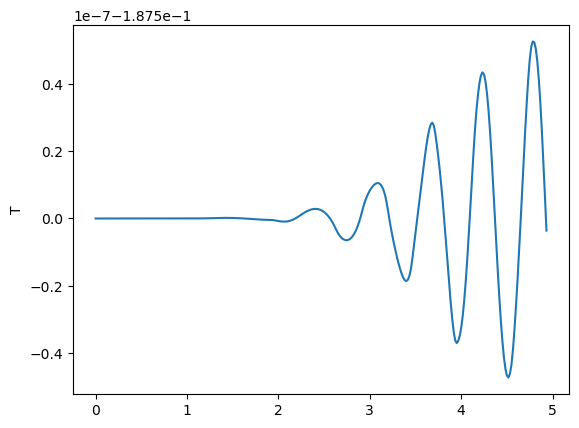

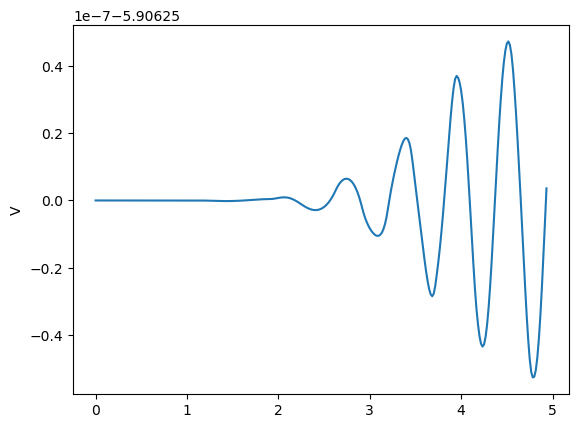

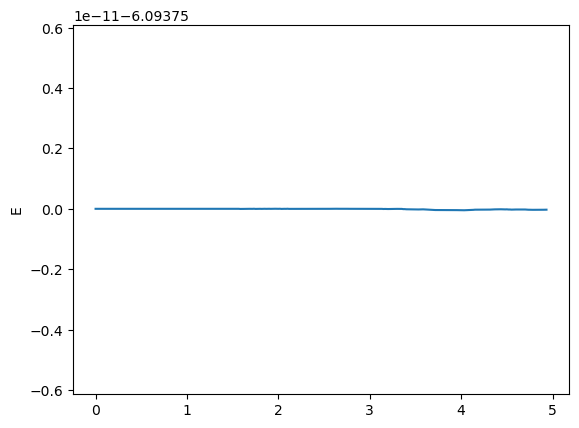

In [132]:
"""
Check energy conservation
"""
# print(Hh0())
print(Hv().shape)

# kinetic first (1body)
Ttot = np.einsum("ijt,ji->t",rho_soln_tdhf,Hh0(),optimize=True)
# now potential (2body)
Vtot = 0.5*np.einsum("ijt,ji->t",rhorho_soln_tdhf,Hv().reshape((2*P)**2,(2*P)**2),optimize=True)
# print(f'V: {V[0].real:.3f},{V[100].real:.3f},{V[200].real:.3f}')
Etot = Ttot + Vtot

plt.plot(soln_tdhf.t,Ttot)
plt.ylabel('T')
plt.show()
plt.plot(soln_tdhf.t,Vtot)
plt.ylabel('V')
plt.show()

plt.plot(soln_tdhf.t,Etot)
plt.ylabel('E')
plt.show()

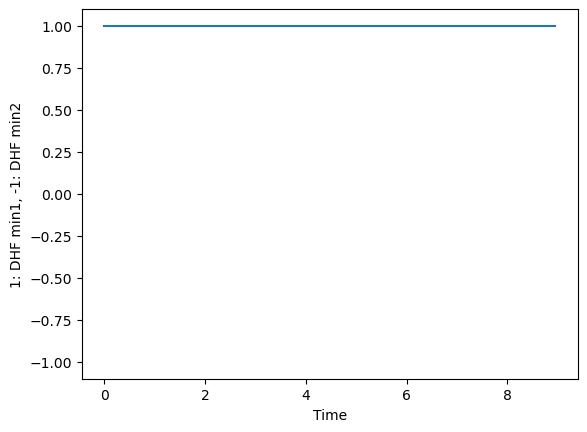

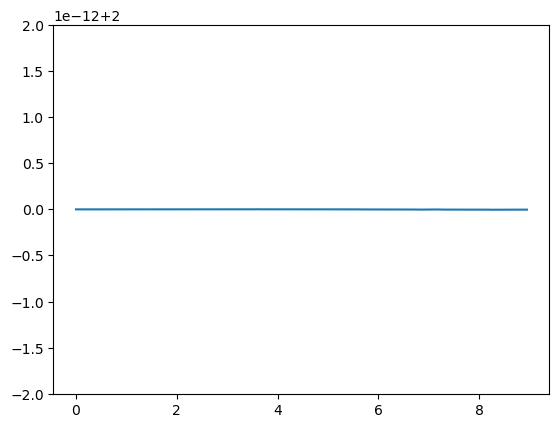

In [60]:
"""
Check number of particles in the bottom 

"""

Jx_tdhf, _, _ = Jobservables(rho_soln_tdhf)
Jdhfmin_tdhf = Jx_tdhf/(0.5*P*np.sin(2*a_dhf))
plt.plot(soln_tdhf.t,Jdhfmin_tdhf)
plt.ylabel('1: DHF min1, -1: DHF min2')
plt.xlabel('Time')
plt.ylim(-1.1,1.1)
plt.show()

nDHFmin_tdhf = DHFobservable(a_dhf,rho_soln_tdhf)
plt.plot(soln_tdhf.t,nDHFmin_tdhf)
plt.show()

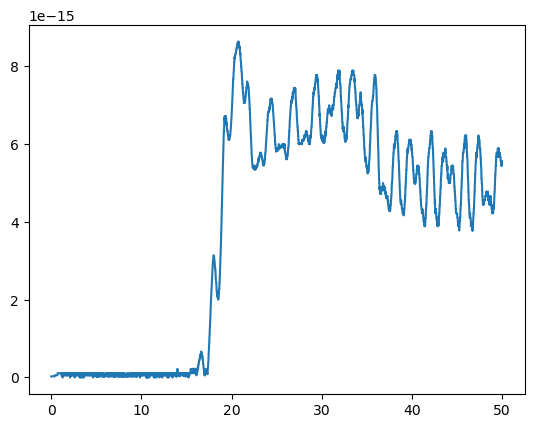

In [23]:
"""
check tdhf property rho^2 = rho
"""

def idempotency_error(rho):
    max = []
    for t in range(len(soln_tdhf.t)):
        max.append(np.max(np.abs(rho[:,:,t] @ rho[:,:,t] - rho[:,:,t])))
    return np.array(max)
plt.plot(soln_tdhf.t,idempotency_error(rho_soln_tdhf))
plt.show()

In [ ]:
''' Check overlap of slaters '''

def slat(th,phi):
    p1 = np.array([np.cos(th/2),0,0,np.exp(-1j*phi)*np.sin(th/2),0,0],dtype=complex)
    p2 = np.array([0,np.cos(th/2),0,0,np.exp(-1j*phi)*np.sin(th/2),0],dtype=complex)
    p3 = np.array([0,0,np.cos(th/2),0,0,np.exp(-1j*phi)*np.sin(th/2)],dtype=complex)
    psiin = np.einsum('i,j,k->ijk',p1,p2,p3)
    # slat=psiin
    slat = 1/np.sqrt(6)*( psiin 
              -np.einsum('ijk->ikj',psiin)
              -np.einsum('ijk->jik',psiin)
              +np.einsum('ijk->jki',psiin)
              +np.einsum('ijk->kij',psiin)
              -np.einsum('ijk->kji',psiin)  )
    return slat.ravel()
print('orthog test for the 2 minima using slaters <1|2>:', slat(np.arccos(eps/(V*P-V)),0).conj().T @ slat(np.arccos(eps/(V*P-V)),np.pi) )

def makerho(th,phi):
    p1 = np.array([np.cos(th/2),0,0,np.exp(-1j*phi)*np.sin(th/2),0,0],dtype=complex)
    p2 = np.array([0,np.cos(th/2),0,0,np.exp(-1j*phi)*np.sin(th/2),0],dtype=complex)
    p3 = np.array([0,0,np.cos(th/2),0,0,np.exp(-1j*phi)*np.sin(th/2)],dtype=complex)
    rho0 = np.outer(p1,p1.conj()) + np.outer(p2,p2.conj()) + np.outer(p3,p3.conj())
    # trace is 3, good
    return rho0

def makeD(th,phi):
    D = antisym_3_full( np.einsum('il,jm,kn->ijklmn',makerho(th,phi),makerho(th,phi),makerho(th,phi)) )
    D = D.reshape(8*P**3,8*P**3)
    return D
print('orthog test for the 2 minima using sqrt(Tr[rho(1)rho(2)])', np.sqrt(np.trace(makeD(np.arccos(eps/(V*P-V)),0) @ makeD(np.arccos(eps/(V*P-V)),np.pi))))